In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve



# 1. Load and Clean Dataset


In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
df = pd.read_csv(url, header=None)

df = df.replace("?", np.nan)
df = df.dropna()
df = df.astype(float)

X = df.iloc[:, :-1]
y = df.iloc[:, -1]
y = (y > 0).astype(int)

# 2. Train/Test Split


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Define Models


In [4]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, solver="lbfgs"),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42)
}

results = {}

# 4. Train & Evaluate Models


In [5]:
for name, model in models.items():
    # Use scaled data for LR & SVM, raw for tree-based
    if name in ["Logistic Regression", "SVM"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:,1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1, "AUC": auc}

    print(f"\n{name} Results:")
    print(f" Accuracy: {acc:.4f}")
    print(f" Precision: {prec:.4f}")
    print(f" Recall: {rec:.4f}")
    print(f" F1-score: {f1:.4f}")
    print(f" AUC: {auc:.4f}")


Logistic Regression Results:
 Accuracy: 0.8333
 Precision: 0.8462
 Recall: 0.7857
 F1-score: 0.8148
 AUC: 0.9498

Decision Tree Results:
 Accuracy: 0.7000
 Precision: 0.6923
 Recall: 0.6429
 F1-score: 0.6667
 AUC: 0.6964

Random Forest Results:
 Accuracy: 0.8500
 Precision: 0.8800
 Recall: 0.7857
 F1-score: 0.8302
 AUC: 0.9408

SVM Results:
 Accuracy: 0.8500
 Precision: 0.8800
 Recall: 0.7857
 F1-score: 0.8302
 AUC: 0.9542


# 5. ROC Curves


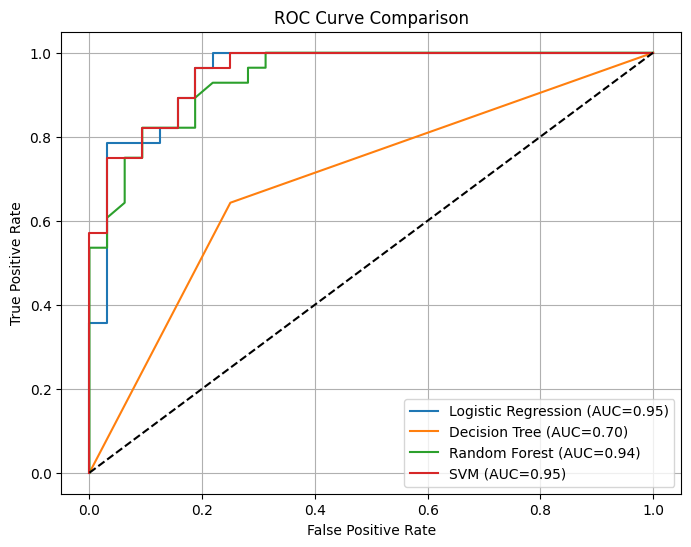

In [6]:
plt.figure(figsize=(8,6))
for name, model in models.items():
    if name in ["Logistic Regression", "SVM"]:
        y_proba = model.predict_proba(X_test_scaled)[:,1]
    else:
        y_proba = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, y_proba):.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()
plt.show()

# Results Table


Model Performance Summary:
                     Accuracy  Precision    Recall        F1       AUC
Logistic Regression  0.833333   0.846154  0.785714  0.814815  0.949777
Decision Tree        0.700000   0.692308  0.642857  0.666667  0.696429
Random Forest        0.850000   0.880000  0.785714  0.830189  0.940848
SVM                  0.850000   0.880000  0.785714  0.830189  0.954241


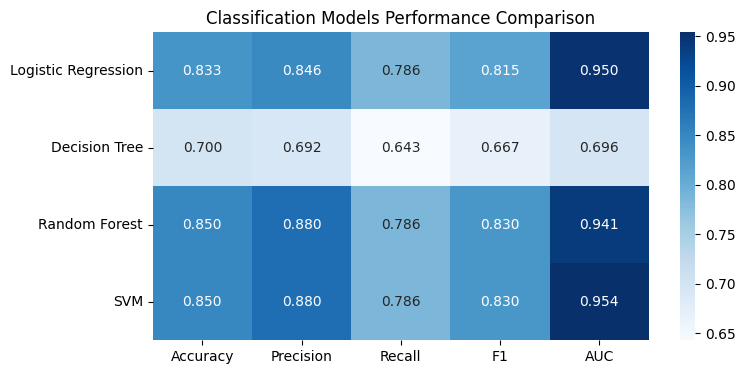

In [7]:
import pandas as pd

# Convert results dictionary to DataFrame
results_df = pd.DataFrame(results).T  # transpose so models are rows

print("\nModel Performance Summary:")
print(results_df)

# Optional: pretty table output
import seaborn as sns
plt.figure(figsize=(8,4))
sns.heatmap(results_df, annot=True, fmt=".3f", cmap="Blues")
plt.title("Classification Models Performance Comparison")
plt.show()